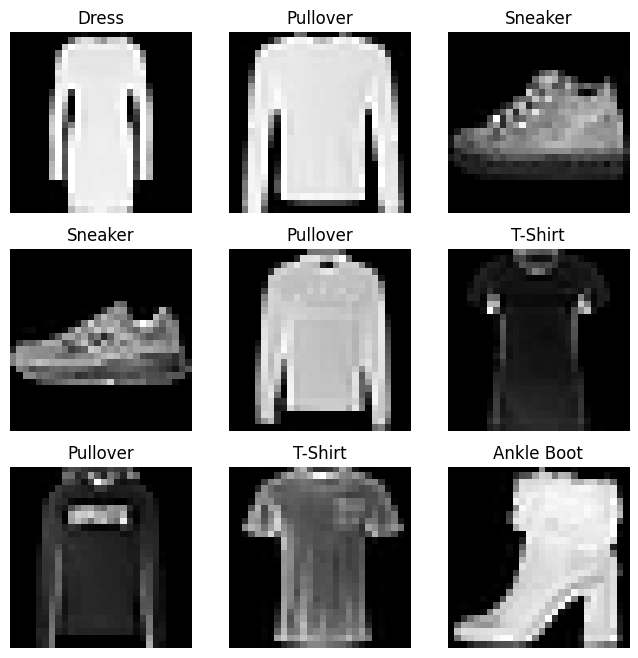

In [9]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [10]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

In [12]:
# CustomImageDataset().__get_item__(0)

img, target = training_data.__getitem__(0)

img.shape

torch.Size([1, 28, 28])

In [8]:
import pprint as pp
from sklearn import datasets
import numpy as np
import torch
from torch.utils.data import Dataset, random_split

# Generate Sample Data
total_samples = 1800
X_data, Y_data = datasets.make_blobs(n_samples=total_samples, n_features=3, centers=[(-2, 5), (3, -4)], random_state=42)


# Create a Custom Dataset Class
class CustomDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __getitem__(self, index):
        sample = {
            'features': torch.tensor(self.x[index], dtype=torch.float32),
            'label': torch.tensor(self.y[index], dtype=torch.long)
        }
        return sample

    def __len__(self):
        return len(self.x)

# Create the Dataset Instance
dataset = CustomDataset(X_data, Y_data)
print("Total number of samples in the dataset:", len(dataset))

# Split the Dataset
train_data, val_data = random_split(dataset, [1200, 600])

print("Number of training samples:", len(train_data))
print("Number of validation samples:", len(val_data))

Total number of samples in the dataset: 1800
Number of training samples: 1200
Number of validation samples: 600


In [7]:
dataset.__getitem__(0)

{'features': tensor([-2.4749,  4.3467]), 'label': tensor(0)}